In [5]:
import random
# pyright: reportFunctionMemberAccess=false


In [ ]:

instance =  [[(0,3), (1,2)], [(1,2), (0,4)]]


print(decode(instance, [1,0,0,1]))
print(decode(instance, [0,1,0,1]))
print(decode(instance, [0,0,1,1]))
print(decode(instance, [1,1,0,0]))

n = len(instance)
m = len({machine for job in instance for machine, _ in job})
print(n,m)

2 2


In [7]:
def decode(instance, sequence) -> int:
    decode.calls += 1
    n = len(instance)
    m = len({machine for job in instance for machine, _ in job})
    if len(sequence) != sum(len(job) for job in instance):
        print("Invalid sequence")
        return -1

    total_makespan = 0

    job_ready = [0 for i in range(n)]
    machine_ready = [0 for i in range(m)]
    job_instr_counters = [0 for i in range(n)]

    for i in sequence:
        m_id, duration = instance[i][job_instr_counters[i]]
        start_ts = max(job_ready[i], machine_ready[m_id])

        job_ready[i ] = start_ts + duration
        machine_ready[m_id] = start_ts + duration


        # print(f"Job {i} on machine {m_id}. start_ts = {start_ts}, finish = {start_ts + duration}")
        # print(machine_ready)
        # print(job_ready)

        job_instr_counters[i] += 1

    return max(job_ready)

decode.calls = 0

In [8]:
print(decode(instance, [1,0,0,1]))
print(decode(instance, [0,1,0,1]))
print(decode(instance, [0,0,1,1]))
print(decode(instance, [1,1,0,0]))

7
7
11
11


In [9]:
def load(filepath):
    with open(filepath, "r") as f:
        n, m = (int(x) for x in f.readline().split(" "))
        instance = [[int(x) for x in f.readline().split(" ")] for i in range(n)]
        instance = [list(zip(job[::2],job[1::2])) for job in instance] 

    return instance

In [10]:
ft06 = load('data/ft06.txt')
len(ft06)              # 6
ft06[0][0]             # (2, 1)
ft06[1]                # [(1,8), (2,5), (4,10), (5,10), (0,10), (3,4)]
decode(ft06, [j for j in range(6) for _ in range(6)])   # 244

152

In [11]:
!pip install more_itertools

In [12]:
[i for i in range(1,2)]

[1]

### Gruba sila

In [13]:
from more_itertools import distinct_permutations

def brute_force(instance):
    possible = [i for i, inst  in enumerate(instance) for j in range(len(inst))]
    best_makespan = float('inf')
    best_sequence = []
    for perm in distinct_permutations(possible):
        makespan = decode(instance, perm)
        if makespan < best_makespan:
            best_makespan = makespan
            best_sequence = list(perm)

    return best_makespan, best_sequence


In [14]:
print([list(perm) for perm in distinct_permutations([0,0,1,1])])

[[0, 0, 1, 1], [0, 1, 0, 1], [0, 1, 1, 0], [1, 0, 0, 1], [1, 0, 1, 0], [1, 1, 0, 0]]


In [15]:
brute_force(instance)

(7, [0, 1, 0, 1])

In [16]:
mini3 = load('data/mini3.txt')

### Pomocne funkcije za pretragu

In [17]:
def replace_in_seq(seq, i, j, inplace=False):
    if not inplace:
        tmp_seq = list(seq)
    else:
        tmp_seq = seq
    tmp = tmp_seq[i]
    tmp_seq[i] = tmp_seq[j]
    tmp_seq[j] = tmp
    return tmp_seq

In [18]:
def neighbors(sequence):
    for i in range(len(sequence)):
        for j in range(i+1, len(sequence)):
            if(sequence[i] != sequence[j]):
                yield replace_in_seq(sequence,i,j)

In [19]:

seq = [0,1,1,2,0,1,2,0,2]
print(len(list(neighbors(seq))))
print( len(set(map(tuple,neighbors(seq)))) )
print(min(decode(mini3, s) for s in neighbors(seq)))


27
27
11


### Lokalna pretraga

In [20]:

def local_search(instance, sequence, firstimprov=False):
    best_score = decode(instance,sequence)
    best_sequence = list(sequence)

    stalled = False
    while not stalled:
        stalled = True
        for neighbor in neighbors(sequence):

            value = decode(instance, neighbor)


            if value < best_score:
                best_score = value
                best_sequence = neighbor
                stalled = False 
                if firstimprov:
                    break

        sequence = best_sequence

    return best_score, best_sequence

In [21]:
local_search(instance, [1,1,0,0])


print("MIN3 problem")
starting_sequence = [j for j in range(3) for _ in range(3)]
print(starting_sequence)
print(decode(mini3, starting_sequence))

print(local_search(mini3,starting_sequence))




MIN3 problem
[0, 0, 0, 1, 1, 1, 2, 2, 2]
20
(11, [2, 0, 0, 1, 1, 1, 2, 0, 2])


In [22]:
def local_search_budget(instance, sequence, budget=100000):
    start = decode.calls
    best_score, best_seq = local_search(instance,sequence)
    while decode.calls - start < budget:
        s = random.sample(sequence, len(sequence))
        value, seq = local_search(instance,s)
        if value < best_score:
            best_score, best_seq = value, seq
    return best_score, best_seq

In [23]:

print(local_search_budget(mini3,starting_sequence))

(11, [2, 0, 0, 1, 1, 1, 2, 0, 2])


In [24]:
!pip install py-cpuinfo

In [25]:
import time

def experiment(instance, name,method, optimum, repeats=30, seed=0, printinfo=True, **kwargs):
    decode.calls = 0
    L = sum(len(job) for job in instance)
    base = [j for j, job in enumerate(instance) for _ in job]
    rng = random.Random(seed)

    t0 = time.perf_counter()
    results = []

    for _ in range(repeats):
        start = rng.sample(base, L)
        if(kwargs):
            score, _ = method(instance, start, **kwargs)
        else:
            score, _ = method(instance, start)
        results.append(score)


    dt = time.perf_counter() - t0

    if printinfo:
        print("===========================")
        print(f"{name}: Started {repeats} optimizations with different starting points.")
        print(f"Took {dt:.1f} seconds. Called decode {decode.calls} times")
        print(f"Best score: {min(results)}, avg: {sum(results)/repeats:.1f}. Worst: {max(results)}")
        print(f"Optimum {optimum}")
        print(f"Local optimums found: {sorted(set(results))}")
        print("===========================")

    result = {
        'time': dt,
        'decode_calls': decode.calls,
        'best_score': min(results),
        'optimum': optimum,
        'optimums': sorted(set(results)),
        'average': sum(results)/repeats,
    }
    return result

In [26]:
ft06 = load('data/ft06.txt')
experiment(ft06, "FT06", local_search, 55, repeats=30, seed=42);

FT06: Started 30 optimizations with different starting points.
Took 1.0 seconds. Called decode 75090 times
Best score: 55, avg: 58.5. Worst: 67
Optimum 55
Local optimums found: [55, 57, 58, 59, 60, 65, 67]


In [27]:
def get_random_neighbor(sequence, inplace=False):
    different = False
    while not different:
        i= random.randrange(0,len(sequence))
        j= random.randrange(0,len(sequence))

        if(sequence[i] != sequence[j]):
            if not inplace:
                tmp_seq = list(sequence)
            else:
                tmp_seq = sequence
            return replace_in_seq(tmp_seq,i,j, inplace=inplace)


In [28]:
import math 

def simulated_annealing(instance, sequence, iters = 1000):
    best_sequence = list(sequence)
    best_score = decode(instance, sequence)
    T = 20
    alpha = (0.001/T)**(1/iters)

    current = sequence
    current_value = decode(instance,sequence)
    for i in range(iters):

        neighbor = get_random_neighbor(current)

        value = decode(instance,neighbor)

        if value < current_value:
            current = neighbor
            current_value = value

            if value < best_score:
                best_sequence = neighbor
                best_score = value

        else:
            delta = abs(current_value-value)

            T *= alpha
            p = math.e ** (- delta / T )
            if random.random() < p:
                current = neighbor
                current_value = value

    return best_score, best_sequence




In [29]:
experiment(ft06,"ft06",simulated_annealing,55,repeats=30,seed=42, iters=10000);

ft06: Started 30 optimizations with different starting points.
Took 4.6 seconds. Called decode 300060 times
Best score: 55, avg: 55.1. Worst: 57
Optimum 55
Local optimums found: [55, 57]


In [30]:
!pip install numpy

In [31]:
import matplotlib.pyplot as plt
import numpy as np

results_annealing = []
iter_range = np.logspace(1,4,20).astype(int)
for iters in iter_range:
    results_annealing.append(
        experiment(ft06,'ft06',simulated_annealing,55,repeats=30,seed=42,printinfo=False, iters=iters,))

# print(iter_range)
# print(list(map(lambda r: r['average'], results)))

results_ls = experiment(ft06, "FT06", local_search, 55, repeats=30, seed=42);

KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (20,) and (16,)

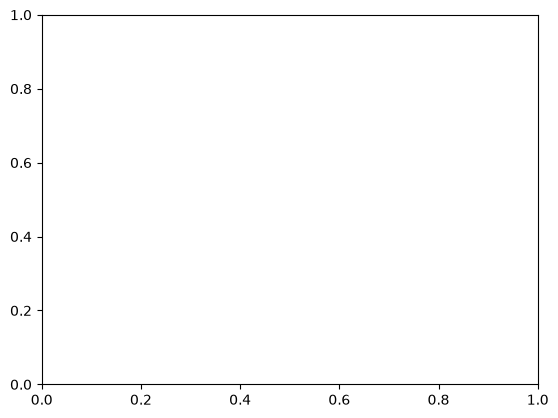

In [32]:

plt.plot(iter_range, list(map(lambda r: r['average'], results_annealing)))
plt.title("Ratio between iterations spent and average optimum")
plt.show()

In [33]:


def plot_results(title, method, lower_bound, results):

    x = [r['decode_calls'] for r in results]
    y = [r['average'] for r in results]
    plt.semilogx(x,y,marker='o',label=method)
    plt.title(title)

    plt.axhline(lower_bound, ls="--", c = 'k', label='lower_bound')
    # plt.scatter(results_ls['decode_calls'], results_ls['average'], c='g', label='local search' )
    plt.xlabel("Number of decode calls")
    plt.ylabel('average makespan')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()




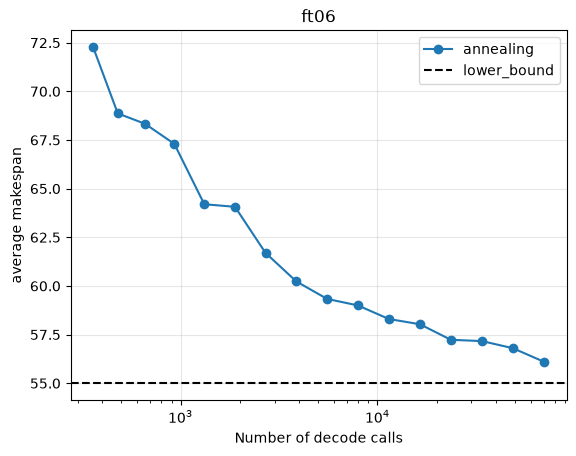

In [34]:
plot_results("ft06", "annealing",55, results_annealing)

In [35]:

results= []
ft10 = load('data/ft10.txt')
iter_range = np.logspace(1,6,10).astype(int)
for iters in iter_range:
    results.append(
        experiment(ft10,'ft10',simulated_annealing,930,repeats=10,seed=42,printinfo=False, iters=iters,))


KeyboardInterrupt: 

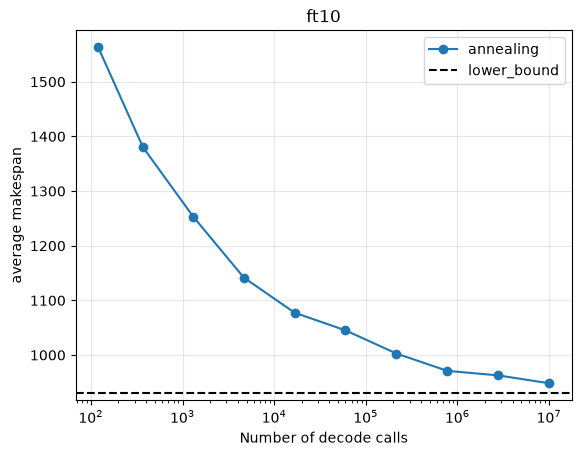

In [ ]:

plot_results("ft10",'annealing',930, results)

In [36]:
def shake(seq, k):
    tmp_seq = list(seq)
    for i in range(k):
        get_random_neighbor(tmp_seq, inplace=True)
    return tmp_seq

In [37]:
def vns(instance, sequence, kmax=10, budget=1000):
    start = decode.calls
    current = sequence
    best_score = decode(instance,current)
    best_seq = current

    while decode.calls - start < budget:
        k = 1
        while k < kmax and decode.calls - start < budget:
            neigbor = shake(current,k)
            value, seq_ret = local_search(instance,neigbor, firstimprov=True)
            if value < best_score:
                best_score = value
                best_seq = seq_ret
                current = seq_ret
                k = 1 
            else:
                k+=1

    return best_score, best_seq


In [38]:
experiment(ft06, 'ft06', vns, 55, 10,seed=42,printinfo=True,budget=100000,kmax=4)


KeyboardInterrupt: 

In [ ]:

results= []
ft10 = load('data/ft10.txt')
iter_range = np.logspace(1,5,10).astype(int)
for iters in iter_range:
    results.append(
        experiment(ft10,'ft10',vns,930,repeats=10,seed=42,printinfo=False, budget=iters,kmax=5))

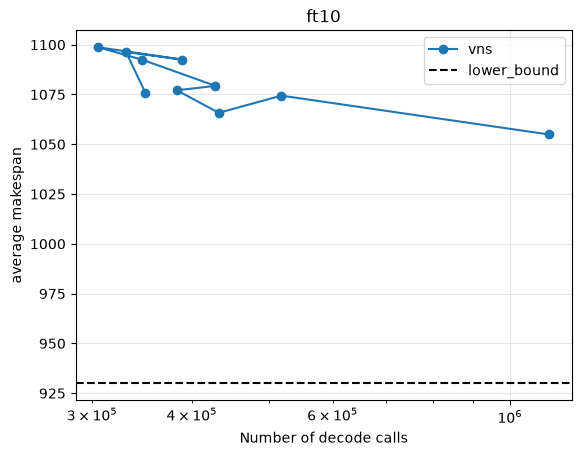

In [ ]:

plot_results("ft10",'vns',930, results)

In [39]:
def reconstruct_path(ancestors, last_finishing_job):
    path = [last_finishing_job]
    while True:
        i, j = path[-1]
        if ancestors[i][j] == None:
            break
        path.append(ancestors[i][j])

    path.reverse()

    return path

def decode_full(instance, sequence):
    critical_path = []
    n = len(instance)
    m = len({machine for job in instance for machine, _ in job})
    if len(sequence) != sum(len(job) for job in instance):
        print("Invalid sequence")
        return {
            'success': False
        }

    total_makespan = 0

    job_ready = [0 for i in range(n)]
    machine_ready = [0 for i in range(m)]
    job_instr_counters = [0 for i in range(n)]

    last_job_on_machine = [None for i in range(m)]

    ancestors = [[None for _ in inst] for inst in instance ]
    pos = {}
    start = {}
    end = {}
    for idx, i in enumerate(sequence):
        m_id, duration = instance[i][job_instr_counters[i]]
        if job_ready[i] > machine_ready[m_id]:
            start_ts = job_ready[i]
            ancestors[i][job_instr_counters[i]] = (i,job_instr_counters[i]-1)
        else:
            start_ts = machine_ready[m_id]
            ancestors[i][job_instr_counters[i]] = last_job_on_machine[m_id]


        job_ready[i ] = start_ts + duration
        machine_ready[m_id] = start_ts + duration
        last_job_on_machine[m_id] = (i, job_instr_counters[i])
        pos[(i,job_instr_counters[i])] = idx
        start[(i,job_instr_counters[i])] = start_ts
        end[(i,job_instr_counters[i])] = start_ts + duration

        if start_ts + duration > total_makespan:
            total_makespan = start_ts + duration
            last_finishing_job = (i, job_instr_counters[i])

        job_instr_counters[i] += 1
        

    path = reconstruct_path(ancestors, last_finishing_job)
    return {
        'success': True,
        'makespan': max(job_ready),
        'critical_path': path,
        'start': start,
        'end': end,
        'seq_pos': pos
    }


In [40]:
print(instance)

[[(0, 3), (1, 2)], [(1, 2), (0, 4)]]


In [41]:
decode_full(instance,[0,1,1,0])

{'success': True,
 'makespan': 7,
 'critical_path': [(0, 0), (1, 1)],
 'start': {(0, 0): 0, (1, 0): 0, (1, 1): 3, (0, 1): 3},
 'end': {(0, 0): 3, (1, 0): 2, (1, 1): 7, (0, 1): 5},
 'seq_pos': {(0, 0): 0, (1, 0): 1, (1, 1): 2, (0, 1): 3}}

In [42]:
decode_full(mini3, [0,1,1,2,0,1,2,0,2])

{'success': True,
 'makespan': 11,
 'critical_path': [(0, 0), (1, 0), (1, 1), (2, 1), (0, 2)],
 'start': {(0, 0): 0,
  (1, 0): 3,
  (1, 1): 5,
  (2, 0): 0,
  (0, 1): 4,
  (1, 2): 6,
  (2, 1): 6,
  (0, 2): 9,
  (2, 2): 9},
 'end': {(0, 0): 3,
  (1, 0): 5,
  (1, 1): 6,
  (2, 0): 4,
  (0, 1): 6,
  (1, 2): 10,
  (2, 1): 9,
  (0, 2): 11,
  (2, 2): 10},
 'seq_pos': {(0, 0): 0,
  (1, 0): 1,
  (1, 1): 2,
  (2, 0): 3,
  (0, 1): 4,
  (1, 2): 5,
  (2, 1): 6,
  (0, 2): 7,
  (2, 2): 8}}

In [43]:
def n1_neighbors(instance, sequence):
    result = decode_full(instance, sequence)
    if not result['success']:
        return None

    path = result['critical_path']
    pos = result['seq_pos']


    n1 = []
    for pair in (zip(path, path[1:])):
        i,j = pair[0]
        k,l = pair[1]

        m1, _ = instance[i][j]
        m2, _ = instance[k][l]

        if m1 == m2:
            n1.append(replace_in_seq(sequence,pos[(i,j)], pos[(k,l)]))

    return n1
            


In [44]:
n1_neighbors(mini3, [0,1,1,2,0,1,2,0,2])

[[1, 0, 1, 2, 0, 1, 2, 0, 2],
 [0, 1, 2, 2, 0, 1, 1, 0, 2],
 [0, 1, 1, 2, 0, 1, 0, 2, 2]]

### Gant diagram

Reference: [Link](https://www.datacamp.com/tutorial/how-to-make-gantt-chart-in-python-matplotlib)

In [ ]:
from matplotlib.patches import Patch 
def gantt(instance, sequence, title="", ax=None, xmax=None):
    result = decode_full(instance,sequence)

    if not result['success']:
        return


    m = len({x for job in instance for x, _ in job})
    critical_path = set(result['critical_path'])

    if ax is None:
        _, ax = plt.subplots(figsize=(10,0.6*m + 1.2))

    colors = plt.cm.tab20(range(20))

    for j, job in enumerate(instance):
        for k, (mid, d) in enumerate(job):
            o = (j, k)
            ax.barh(y = mid, width=d, left=result['start'][o],
                    color = colors[j % 20],
                    edgecolor='black' if o in critical_path else 'none',
                    hatch='///' if o in critical_path else None,zorder=3)



    ax.set_yticks(range(m))
    ax.set_yticklabels([f"M{i}" for i in range(m)])
    ax.invert_yaxis()
    ax.set_xlabel("vreem")
    ax.set_xlim(0,(xmax or result['makespan'])* 1.02)
    ax.set_title(f"{title}, makespan = {result['makespan']}")
    ax.grid(axis='x',alpha=0.3)

    ax.legend(handles=
              [Patch(facecolor=colors[j % 20], label=f"Job {j}") for j in range(len(instance))],
              fontsize=7, ncol=2)
    return result['makespan']



    



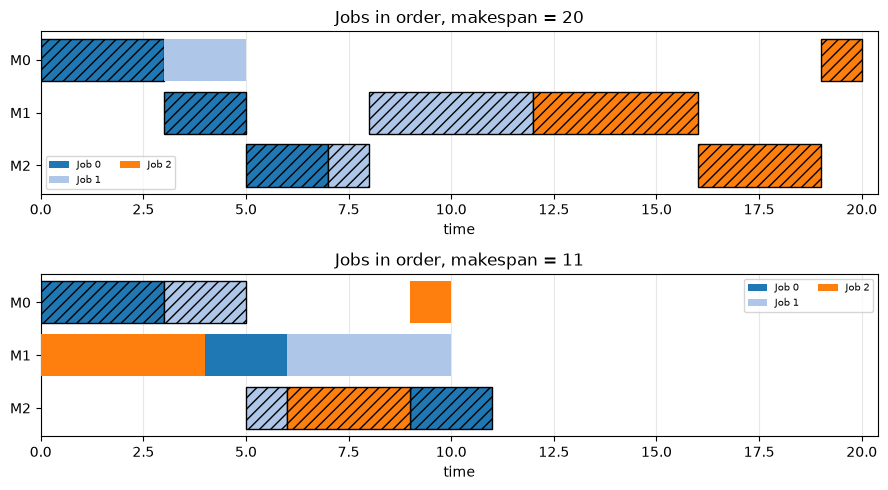

In [46]:
ordered =[0,0,0,1,1,1,2,2,2] 
optimum = [0,1,1,2,0,1,2,0,2]
xmax = max(decode(mini3, ordered), decode(mini3,optimum))

fig, axes = plt.subplots(2,1, figsize=(9,5))
gantt(mini3, ordered, "Jobs in order", axes[0], xmax=xmax)
gantt(mini3, optimum, "Jobs in order", axes[1], xmax=xmax)
plt.tight_layout()


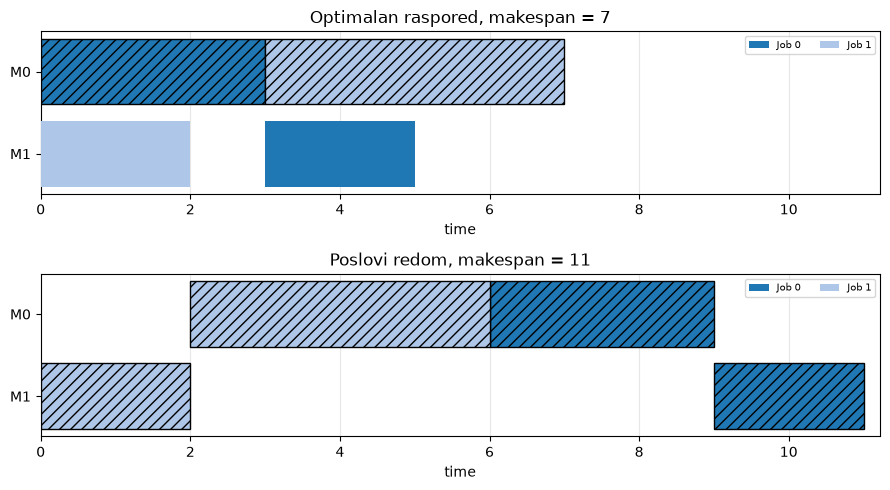

In [60]:

instance =  [[(0,3), (1,2)], [(1,2), (0,4)]]


ordered =[1,1,0,0] 
optimum = [1,0,0,1] 
xmax = max(decode(instance, ordered), decode(instance,optimum))

fig, axes = plt.subplots(2,1, figsize=(9,5))
gantt(instance, ordered, "Poslovi redom", axes[1], xmax=xmax)
gantt(instance, optimum, "Optimalan raspored", axes[0], xmax=xmax)
plt.tight_layout()

In [47]:
def lower_bound(instance):

    longest_per_job = max(
        sum((dur for _, dur in job)) for job in instance)

    m = len(set(m_id for job in instance for (m_id,_) in job))
    machine_lengths = [0] * m

    for job in instance:
        for (m_id, dur) in job:
            machine_lengths[m_id] += dur

    longest_per_machine = max(machine_lengths)

    return max(longest_per_job, longest_per_machine)
        

In [48]:
lower_bound(ft06)

47

# Genetic algorithm

In [49]:
def crossover(parent1, parent2):
    mask = [random.randrange(2) for i in range(len(parent1))]

    p1 = list(parent1)
    p2 = list(parent2)

    c1 = []
    for idx, bit in enumerate(mask):
        if bit:
            c1.append(p1[0])
            p2.remove(p1[0])
            p1.pop(0)
        else:
            c1.append(p2[0])
            p1.remove(p2[0])
            p2.pop(0)

    return c1
            

def select_parent(seq):
    return min(seq, key=(lambda x: x[1]))

def mutation(el, p, inplace=True):

    if random.random() < p:
        return get_random_neighbor(el,inplace=inplace)
    return el



In [50]:
def genetic_algorithm(instance, sequence, budget=100000,population_size=50, p = 0.3, elitism = 0.02, tournament_pct=0.3):

    starting_population = [random.sample(sequence, len(sequence)) for i in range(population_size)]


    start = decode.calls

    best_seen = (starting_population[0], decode(instance,starting_population[0]))

    TOUR_SIZE = int(tournament_pct * len(starting_population))
    ELITISM = int(population_size * elitism)

    current_scores = [(seq, decode(instance,seq)) for seq in starting_population]
    current_scores.sort(key=(lambda x: x[1]))
    generation = 0
    while decode.calls - start < budget:
        generation += 1


        next_generation = list(current_scores[:ELITISM])

        for i in range(ELITISM, len(current_scores), 2):
            p1 = select_parent(random.sample(current_scores[ELITISM:],TOUR_SIZE))
            p2 = select_parent(random.sample(current_scores[ELITISM:],TOUR_SIZE))

            c1 = crossover(p1[0],p2[0])
            c2 = crossover(p1[0],p2[0])

            c1 = mutation(c1,p=p,inplace=True)
            c2 = mutation(c2,p=p,inplace=True)


            next_generation.append((c1,decode(instance, c1)))
            next_generation.append((c2,decode(instance, c2)))

            

        next_generation.sort(key=(lambda x: x[1]))
        
        current_scores = next_generation
        if(current_scores[0][1] < best_seen[1]):
            best_seen = current_scores[0]

    return best_seen[1], best_seen[0]

    
    




In [51]:
genetic_algorithm(mini3, sequence=[0,0,0,1,1,1,2,2,2], budget=200000, elitism=1, tournament_pct=0.3)

KeyboardInterrupt: 

In [ ]:

results= []
ft10 = load('data/ft10.txt')
iter_range = np.logspace(1,5,10).astype(int)
for iters in iter_range:
    results.append(
        experiment(ft10,'ft10',genetic_algorithm,930,repeats=10,seed=42,printinfo=False, 
                   budget=iters,population_size=50,p=0.3,elitism=0.2))

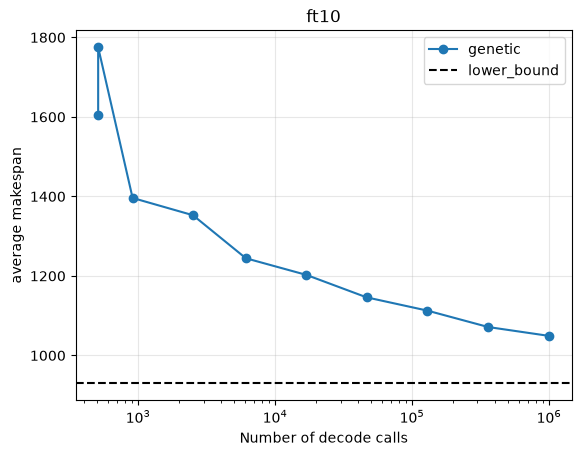

In [ ]:

plot_results("ft10",'genetic',930, results)

In [ ]:
import  csv, os
import numpy as np
import pandas as pd
from jsp import *

BUDGET_RANGE  = np.logspace(3, 6, 8).astype(int)      # 1 000 … 1 000 000
INSTANCES = [("ft06", 55), ("ft10", 930), ("ft20", 1165)]
METHODS   = {"annealing": simulated_annealing,
            "vns": vns,
            "ga": genetic_algorithm,
            "local_search": local_search_budget}
REPEATS = 5

with open("results/budget.csv", "w", newline="") as f:
    w = csv.writer(f)

    w.writerow(["instance", "method", "budget", "decode_calls",
                "best", "average", "optimum", "time"])

    for name, opt in INSTANCES:
        inst = load(f"data/{name}.txt")
        for method_name, method in METHODS.items():
            for b in BUDGET_RANGE:
                r = experiment(inst, name, method, opt,
                               repeats=REPEATS, seed=42,
                               printinfo=False, budget=int(b))
                w.writerow([name, method_name, int(b),
                            r["decode_calls"],
                            r["best_score"], round(r["average"], 2),
                            opt, round(r["time"], 1)])
                f.flush()
                print(f"{name:6} {method_name:13} {b:>8} -> "
                      f"{r['average']:7.1f}  ({r['time']:.0f}s)", flush=True)

ft06   annealing         1000 →    56.6  (0s)
ft06   annealing         2682 →    55.0  (0s)
ft06   annealing         7196 →    55.0  (1s)
ft06   annealing        19306 →    55.0  (2s)
ft06   annealing        51794 →    55.0  (4s)
ft06   annealing       138949 →    55.0  (10s)
ft06   annealing       372759 →    55.0  (26s)
ft06   annealing      1000000 →    55.0  (72s)
ft06   vns               1000 →    58.8  (0s)
ft06   vns               2682 →    57.6  (0s)
ft06   vns               7196 →    56.2  (0s)
ft06   vns              19306 →    55.0  (1s)
ft06   vns              51794 →    55.6  (3s)
ft06   vns             138949 →    55.0  (9s)
ft06   vns             372759 →    55.0  (23s)
ft06   vns            1000000 →    55.0  (60s)
ft06   ga                1000 →    58.8  (0s)
ft06   ga                2682 →    56.4  (1s)
ft06   ga                7196 →    57.0  (1s)
ft06   ga               19306 →    56.2  (4s)
ft06   ga               51794 →    55.0  (10s)
ft06   ga              13894

In [54]:
import csv, time, random, math

def local_search_nb(instance, sequence, neighborhood, budget):
    start = decode.calls
    best_score, best_seq = float("inf"), None

    while decode.calls - start < budget:
        current = random.sample(sequence, len(sequence))
        current_value = decode(instance, current)

        while decode.calls - start < budget:
            candidate, candidate_value = None, current_value
            for neighbor in neighborhood(instance, current):
                value = decode(instance, neighbor)
                if decode.calls - start >= budget:
                    break
                if value < candidate_value:
                    candidate, candidate_value = neighbor, value
            if candidate is None:
                break
            current, current_value = candidate, candidate_value

        if current_value < best_score:
            best_score, best_seq = current_value, current

    return best_score, best_seq


def annealing_nb(instance, sequence, move, budget, T0=20.0, Tk=0.001):
    start = decode.calls
    current = list(sequence)
    current_value = decode(instance, current)
    best_score, best_seq = current_value, list(current)

    alpha = (Tk / T0) ** (1.0 / budget)
    T = T0

    while decode.calls - start < budget:
        neighbor = move(instance, current)
        value = decode(instance, neighbor)
        delta = value - current_value

        if delta < 0 or (T > 1e-12 and random.random() < math.exp(-delta / T)):
            current, current_value = neighbor, value
            if value < best_score:
                best_score, best_seq = value, list(neighbor)
        T *= alpha

    return best_score, best_seq


In [55]:

def swap_neighborhood(instance, sequence):
    return neighbors(sequence)

def n1_neighborhood(instance, sequence):
    return n1_neighbors(instance, sequence) or []

def random_swap_move(instance, sequence):
    return get_random_neighbor(sequence)

def random_n1_move(instance, sequence):
    candidates = n1_neighbors(instance, sequence)
    return random.choice(candidates) if candidates else get_random_neighbor(sequence)


In [56]:
N1_INSTANCES = [("ft06", 55), ("ft10", 930), ("ft20", 1165)]

for name, _ in N1_INSTANCES:
    instance = load(f"data/{name}.txt")
    base = [j for j, job in enumerate(instance) for _ in job]
    random.seed(3)
    total_swap = total_n1 = 0
    for _ in range(200):
        s = random.sample(base, len(base))
        total_swap += len(list(neighbors(s)))
        total_n1   += len(n1_neighbors(instance, s) or [])
    print(f"{name:6} swap {total_swap/200:7.1f}   N1 {total_n1/200:6.1f}"
          f"   ratio {total_swap/total_n1:6.1f}x")


ft06   swap   540.0   N1    6.7   ratio   80.6x
ft10   swap  4500.0   N1   17.4   ratio  259.3x
ft20   swap  4750.0   N1   31.6   ratio  150.4x


In [57]:
BUDGET, REPEATS = 200_000, 10

SETUPS = [
    ("local_search", "swap", lambda i, s, b: local_search_nb(i, s, swap_neighborhood, b)),
    ("local_search", "n1",   lambda i, s, b: local_search_nb(i, s, n1_neighborhood, b)),
    ("annealing",    "swap", lambda i, s, b: annealing_nb(i, s, random_swap_move, b)),
    ("annealing",    "n1",   lambda i, s, b: annealing_nb(i, s, random_n1_move, b)),
]

with open("results/n1.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["instance", "method", "neighborhood", "run", "seed",
                     "makespan", "decode_calls", "time", "optimum"])

    for name, optimum in N1_INSTANCES:
        instance = load(f"data/{name}.txt")
        base = [j for j, job in enumerate(instance) for _ in job]

        for method, neighborhood, run_fn in SETUPS:
            for r in range(REPEATS):
                seed = 1000 * r + 7
                random.seed(seed)
                start_seq = random.sample(base, len(base))

                decode.calls = 0
                t0 = time.perf_counter()
                score, _ = run_fn(instance, start_seq, BUDGET)
                dt = time.perf_counter() - t0

                writer.writerow([name, method, neighborhood, r, seed, score,
                                 decode.calls, round(dt, 2), optimum])
                f.flush()
                print(f"{name:6} {method:13} {neighborhood:5} {r:2} -> {score}", flush=True)


ft06   local_search  swap   0 -> 55
ft06   local_search  swap   1 -> 55
ft06   local_search  swap   2 -> 55
ft06   local_search  swap   3 -> 55
ft06   local_search  swap   4 -> 55
ft06   local_search  swap   5 -> 55
ft06   local_search  swap   6 -> 55
ft06   local_search  swap   7 -> 55
ft06   local_search  swap   8 -> 55
ft06   local_search  swap   9 -> 55
ft06   local_search  n1     0 -> 55
ft06   local_search  n1     1 -> 55
ft06   local_search  n1     2 -> 55
ft06   local_search  n1     3 -> 55
ft06   local_search  n1     4 -> 55
ft06   local_search  n1     5 -> 55
ft06   local_search  n1     6 -> 55
ft06   local_search  n1     7 -> 55
ft06   local_search  n1     8 -> 55
ft06   local_search  n1     9 -> 55
ft06   annealing     swap   0 -> 55
ft06   annealing     swap   1 -> 55
ft06   annealing     swap   2 -> 55
ft06   annealing     swap   3 -> 55
ft06   annealing     swap   4 -> 55
ft06   annealing     swap   5 -> 55
ft06   annealing     swap   6 -> 55
ft06   annealing     swap   